Iter  xl              xu              xr                   f(xr)                ea             
2     40.0000000000   62.3024653506   60.2188277874        0.1208481059         3.4601098024   
3     40.0000000000   60.2188277874   59.9877961753        0.0132959441         0.3851310214   
4     40.0000000000   59.9877961753   59.9624099109        0.0014596827         0.0423369648   
5     40.0000000000   59.9624099109   59.9596232929        0.0001602117         0.0046474908   
6     40.0000000000   59.9596232929   59.9593174443        0.0000175840         0.0005100936   

The root is 59.9593174443 (Approx.)


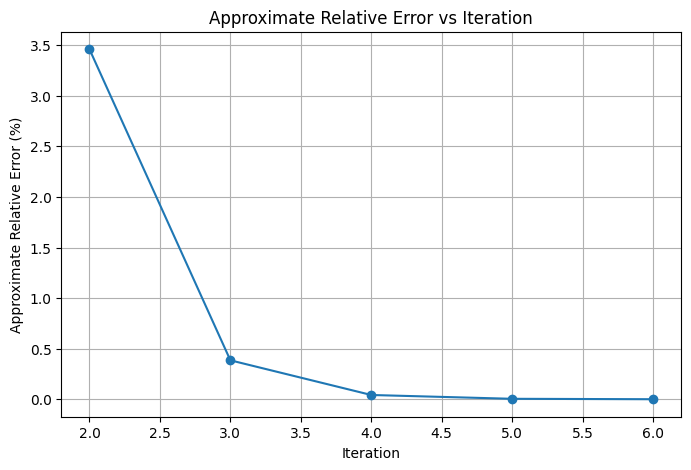

In [3]:
#False position method of finding roots
import numpy as np
import matplotlib.pyplot as plt
import math

#False position function
def false_pos(x):
  g = 9.81
  y = 36
  c = 15
  t = 10
  A = (g * x) / c
  B = 1 - math.exp(-(c/x) * t)
  result = A * B - y
  return result

#Given data
xl = 40
xu = 80
es = 0.001
ea = 100
old_root = xl
i = 0

#Plotting Criterion
iterations = []
approx_errors = []

#Root checking logic
if false_pos(xl)*false_pos(xu) > 0:
  print("There is no root within this range!")
else:
  print(f"{'Iter':<5} {'xl':<15} {'xu':<15} {'xr':<20} {'f(xr)':<20} {'ea':<15}")
  while ea > es:
    i += 1
    root = (xl*false_pos(xu) - xu*false_pos(xl))/(false_pos(xu) - false_pos(xl))

    if i > 1:
      ea = abs(root - old_root)/root * 100
      print(f"{i:<5} {xl:<15.10f} {xu:<15.10f} {root:<20.10f} {false_pos(root):<20.10f} {ea:<15.10f}")

      iterations.append(i)
      approx_errors.append(ea)

    if false_pos(xl)*false_pos(root) < 0:
      xu = root
    else:
      xl = root
    old_root = root
  print(f"\nThe root is {root:.10f} (Approx.)")

#Graph Plot
plt.figure(figsize=(8,5))
plt.plot(iterations, approx_errors, marker='o')
plt.title('Approximate Relative Error vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Approximate Relative Error (%)')
plt.grid(True)
plt.show()